In [2]:
import re
import matplotlib.pyplot as plt
import numpy as np


In [3]:

# Parse the slurm output
epochs, tr_loss, va_loss, va_acc = [], [], [], []
unstruct, inter, struct = [], [], []

with open("/home/zofia/Research/spartannotes/slurm-23800544.out") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    m = re.match(r"epoch (\d+) \| train loss=([\d.]+) acc=([\d.]+) \| val loss=([\d.]+) acc=([\d.]+)", line)
    if m:
        epochs.append(int(m.group(1)))
        tr_loss.append(float(m.group(2)))
        va_loss.append(float(m.group(4)))
        va_acc.append(float(m.group(5)))
    
    # the per-class line comes right after
    cm = re.search(r"\[unstruct \| inter \| struct\]: ([\d.]+) \| ([\d.]+) \| ([\d.]+)", line)
    if cm:
        unstruct.append(float(cm.group(1)))
        inter.append(float(cm.group(2)))
        struct.append(float(cm.group(3)))

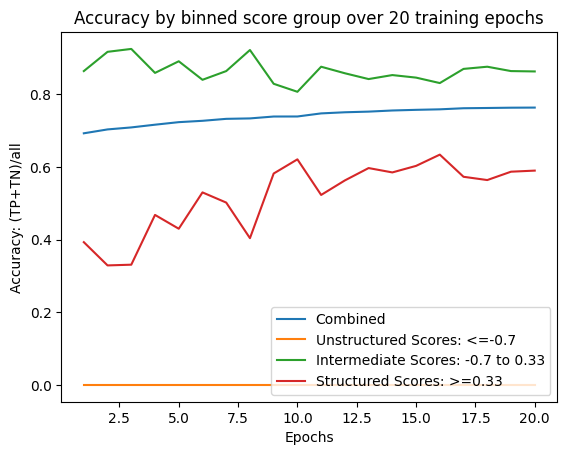

<Figure size 640x480 with 0 Axes>

In [6]:
plt.plot(epochs, va_acc, label="Combined")
plt.plot(epochs, unstruct, label="Unstructured Scores: <=-0.7")
plt.plot(epochs, inter, label="Intermediate Scores: -0.7 to 0.33")
plt.plot(epochs, struct, label="Structured Scores: >=0.33")
plt.xlabel("Epochs")
plt.ylabel("Accuracy: (TP+TN)/all")
plt.title("Accuracy by binned score group over 20 training epochs")
plt.legend(loc="lower right")
plt.show()
plt.savefig("Accuracy by binned score group over 20 training epochs")